170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1583s 9us/step
Train: (4000, 32, 32, 3) Val: (2000, 32, 32, 3) Test: (10000, 32, 32, 3)


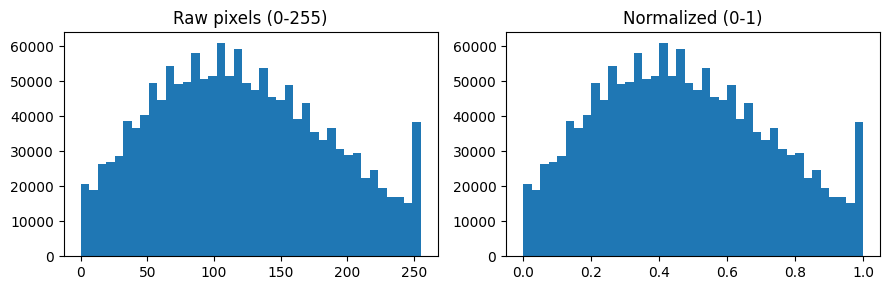

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x, y), (x_test, y_test) = keras.datasets.cifar10.load_data()
x, x_test = x.astype("float32"), x_test.astype("float32")
y, y_test = y.ravel(), y_test.ravel()
x_train, y_train = x[:4000], y[:4000]
x_val, y_val = x[-2000:], y[-2000:]
print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(x_train[:500].ravel(), bins=40); ax[0].set_title("Raw pixels (0-255)")
ax[1].hist(x_train[:500].ravel() / 255.0, bins=40); ax[1].set_title("Normalized (0-1)")
plt.tight_layout(); plt.show()

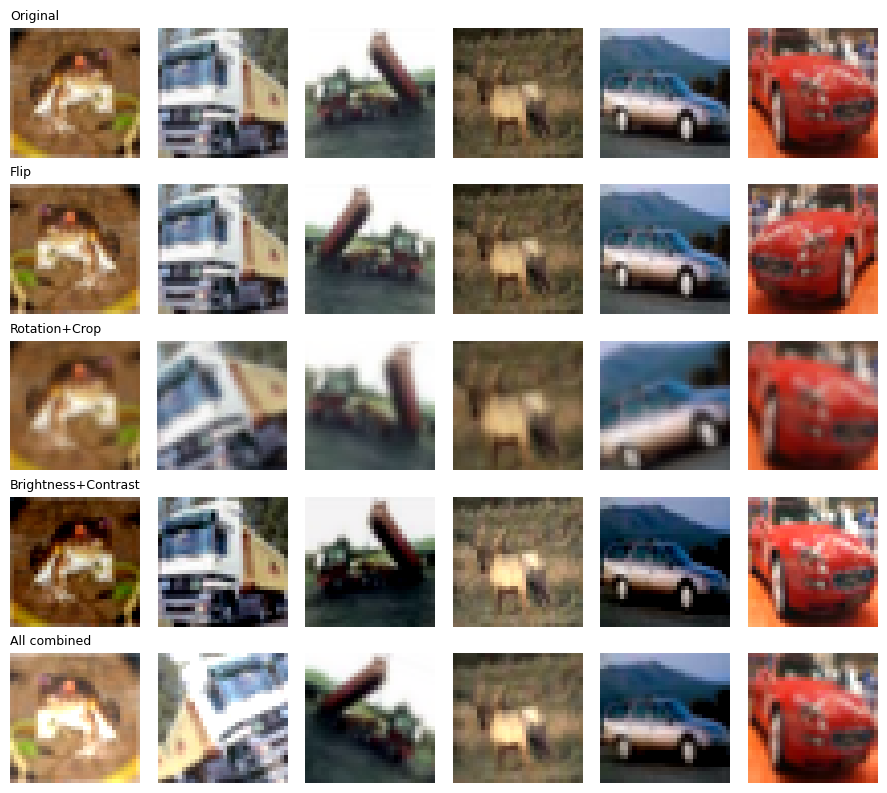

Augmented dataset created: (4000, 32, 32, 3)


In [ ]:
augs = {
    "Flip": layers.RandomFlip("horizontal"),
    "Rotation+Crop": keras.Sequential([layers.RandomRotation(0.08), layers.RandomZoom((-0.2, 0.0))]),
    "Brightness+Contrast": keras.Sequential([layers.RandomBrightness(0.2), layers.RandomContrast(0.3)]),
}
combined = keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.08),
                             layers.RandomBrightness(0.2), layers.RandomContrast(0.3)])

imgs = x_train[:6]
rows = [("Original", imgs)] + [(n, l(imgs, training=True).numpy()) for n, l in augs.items()] \
       + [("All combined", combined(imgs, training=True).numpy())]
fig, ax = plt.subplots(len(rows), 6, figsize=(9, 1.6 * len(rows)))
for i, (n, r) in enumerate(rows):
    for j in range(6):
        ax[i, j].imshow(np.clip(r[j], 0, 255).astype("uint8")); ax[i, j].axis("off")
    ax[i, 0].set_title(n, loc="left", fontsize=9)
plt.tight_layout(); plt.show()

x_aug = combined(x_train, training=True).numpy().astype("uint8")
np.savez_compressed("augmented_cifar10_subset.npz", x=x_aug, y=y_train)
print("Augmented dataset created:", x_aug.shape)

In [ ]:
results, hist = [], {}

def run(name, aug=None):
    keras.utils.set_random_seed(42)
    inp = keras.Input(shape=(32, 32, 3))
    h = aug(inp) if aug is not None else inp
    h = layers.Rescaling(1 / 255.0)(h)
    h = layers.Conv2D(16, 3, activation="relu")(h); h = layers.MaxPooling2D()(h)
    h = layers.Conv2D(32, 3, activation="relu")(h); h = layers.MaxPooling2D()(h)
    h = layers.Flatten()(h); h = layers.Dense(64, activation="relu")(h)
    m = keras.Model(inp, layers.Dense(10, activation="softmax")(h))
    m.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
    hs = m.fit(x_train, y_train, epochs=8, batch_size=128, validation_data=(x_val, y_val), verbose=0)
    tr = m.evaluate(x_train, y_train, verbose=0)[1]
    va = m.evaluate(x_val, y_val, verbose=0)[1]
    te = m.evaluate(x_test, y_test, verbose=0)[1]
    results.append(dict(model=name, train_acc=round(tr, 4), val_acc=round(va, 4), test_acc=round(te, 4), gap=round(tr - va, 4)))
    hist[name] = hs.history
    print(name, "| test", round(te, 4), flush=True)

run("Baseline")
for n, a in augs.items(): run(n, aug=a)
run("All combined", aug=combined)

Baseline | test 0.4657
Flip | test 0.471
Rotation+Crop | test 0.4063
Brightness+Contrast | test 0.4675
All combined | test 0.4417


,model,train_acc,val_acc,test_acc,gap,test_change_vs_baseline
0,Baseline,0.5265,0.4675,0.4657,0.0590,0.00
1,Flip,0.5090,0.4655,0.4710,0.0435,0.53
2,Rotation+Crop,0.4397,0.4150,0.4063,0.0247,-5.94
3,Brightness+Contrast,0.5385,0.4680,0.4675,0.0705,0.18
4,All combined,0.4735,0.4355,0.4417,0.0380,-2.40


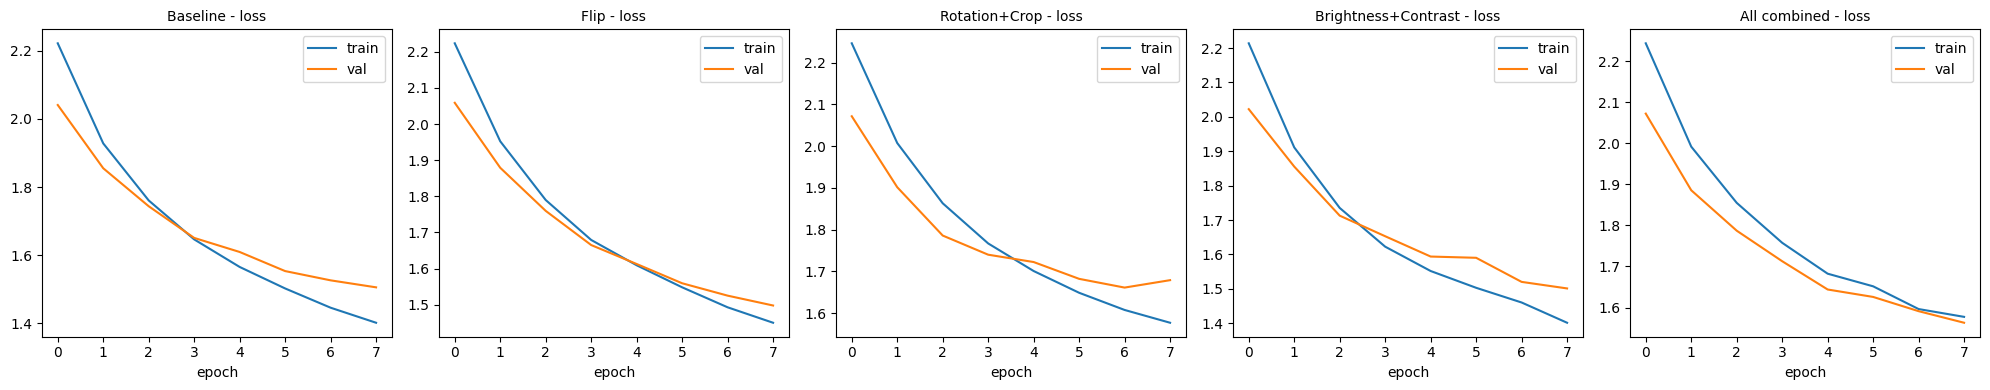

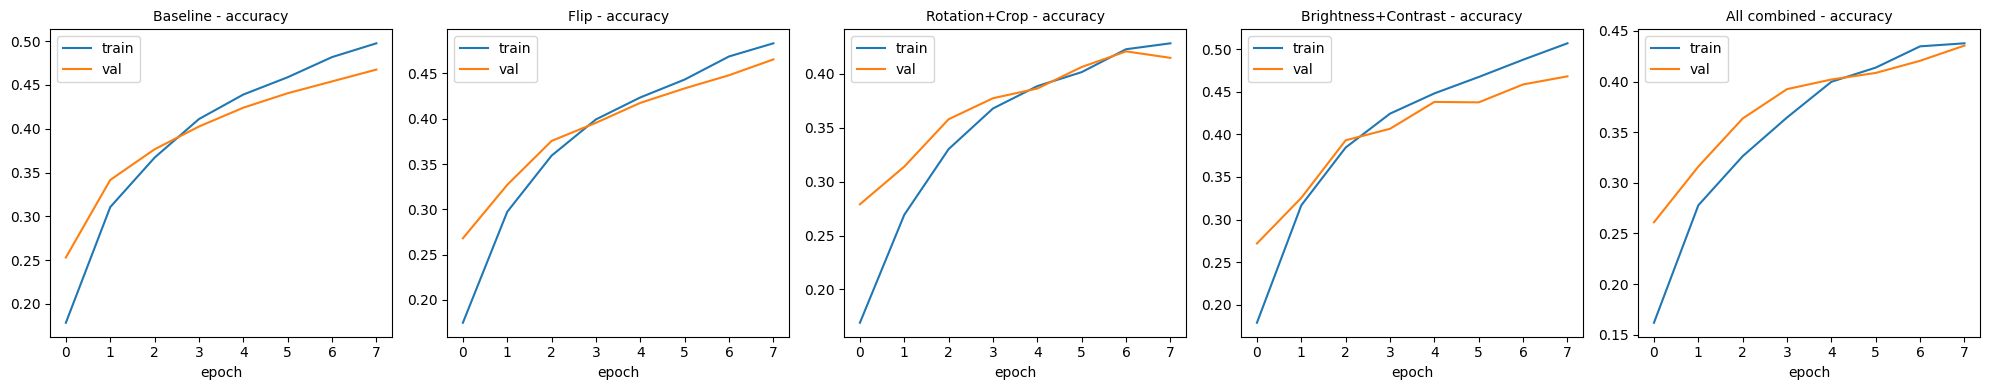

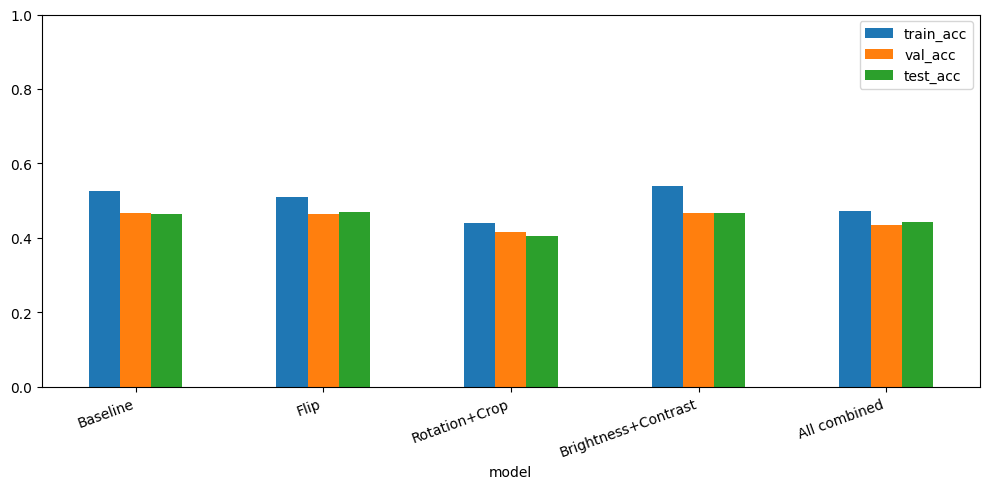

In [ ]:
df = pd.DataFrame(results)
df["test_change_vs_baseline"] = ((df["test_acc"] - df.loc[0, "test_acc"]) * 100).round(2)
display(df)

def curves(key):
    fig, ax = plt.subplots(1, 5, figsize=(20, 4))
    for a, (name, h) in zip(ax, hist.items()):
        a.plot(h[key], label="train"); a.plot(h["val_" + key], label="val")
        a.set_title(f"{name} - {key}", fontsize=10); a.set_xlabel("epoch"); a.legend()
    plt.tight_layout(); plt.show()
curves("loss"); curves("accuracy")

ax = df.set_index("model")[["train_acc", "val_acc", "test_acc"]].plot.bar(figsize=(10, 5), ylim=(0, 1.0))
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()